# 窗函数对比：参考 sin² 窗 vs Hann / Blackman / Hamming

比较 phase vocoder 参考代码（mini_pvdr）中使用的 $\sin^2$ 窗（$\sqrt{8/3}$ 缩放）与标准窗函数的时域和频域特性。

参考窗定义：$w[n] = \sqrt{8/3} \cdot \sin^2\left(\frac{\pi n}{N}\right)$

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows
import scipy.fft as fft

# 中文字体配置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DengXian']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True

N = 512   # 窗长度
fs = 48000  # 用于频率轴标注

## 1. 定义窗函数

- **参考窗 (Ref)**：`sqrt(8/3) * sin²(πn/N)` — mini_pvdr 中使用
- **Hann**：`0.5 - 0.5*cos(2πn/N)`
- **Blackman**：`0.42 - 0.5*cos(2πn/N) + 0.08*cos(4πn/N)`
- **Hamming**：`0.54 - 0.46*cos(2πn/N)`

In [15]:
def ref_window(N):
    """参考 sin² 窗: sqrt(8/3) * sin²(πn/N)"""
    n = np.arange(N)
    return np.sqrt(8.0 / 3.0) * np.sin(np.pi * n / N) ** 2

def hann_window(N):
    """标准 Hann 窗"""
    n = np.arange(N)
    return 0.5 - 0.5 * np.cos(2 * np.pi * n / N)

def blackman_window(N):
    """标准 Blackman 窗"""
    n = np.arange(N)
    return 0.42 - 0.5 * np.cos(2 * np.pi * n / N) + 0.08 * np.cos(4 * np.pi * n / N)

def hamming_window(N):
    """标准 Hamming 窗"""
    n = np.arange(N)
    return 0.54 - 0.46 * np.cos(2 * np.pi * n / N)

# 也可以用 scipy 验证
w_ref = ref_window(N)
w_hann = hann_window(N)
w_black = blackman_window(N)
w_hamm = hamming_window(N)

print("窗函数已生成，长度 N =", N)

窗函数已生成，长度 N = 512


## 2. 时域波形对比

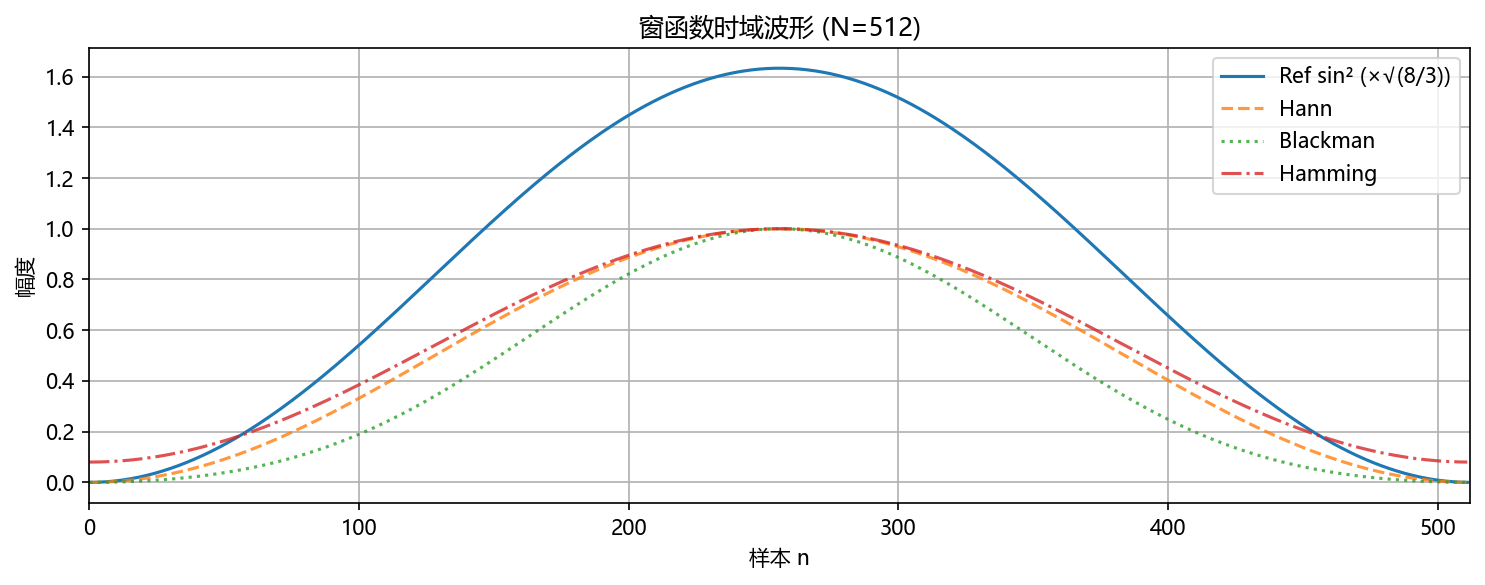

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
n_plot = np.arange(N)

ax.plot(n_plot, w_ref, label='Ref sin² (×√(8/3))', linewidth=1.5)
ax.plot(n_plot, w_hann, '--', label='Hann', linewidth=1.5, alpha=0.8)
ax.plot(n_plot, w_black, ':', label='Blackman', linewidth=1.5, alpha=0.8)
ax.plot(n_plot, w_hamm, '-.', label='Hamming', linewidth=1.5, alpha=0.8)

ax.set_xlabel('样本 n')
ax.set_ylabel('幅度')
ax.set_title(f'窗函数时域波形 (N={N})')
ax.legend()
ax.set_xlim(0, N)
fig.tight_layout()
plt.show()

## 3. 频域幅度响应对比

对窗函数做零填充 FFT (8192 点)，分析其频谱特性。

Ref sin²    : 主瓣 -3dB 带宽 = 140.6 Hz, 最大旁瓣 = -12.4 dB
Hann        : 主瓣 -3dB 带宽 = 140.6 Hz, 最大旁瓣 = -12.4 dB
Blackman    : 主瓣 -3dB 带宽 = 164.1 Hz, 最大旁瓣 = -10.6 dB
Hamming     : 主瓣 -3dB 带宽 = 128.9 Hz, 最大旁瓣 = -13.6 dB


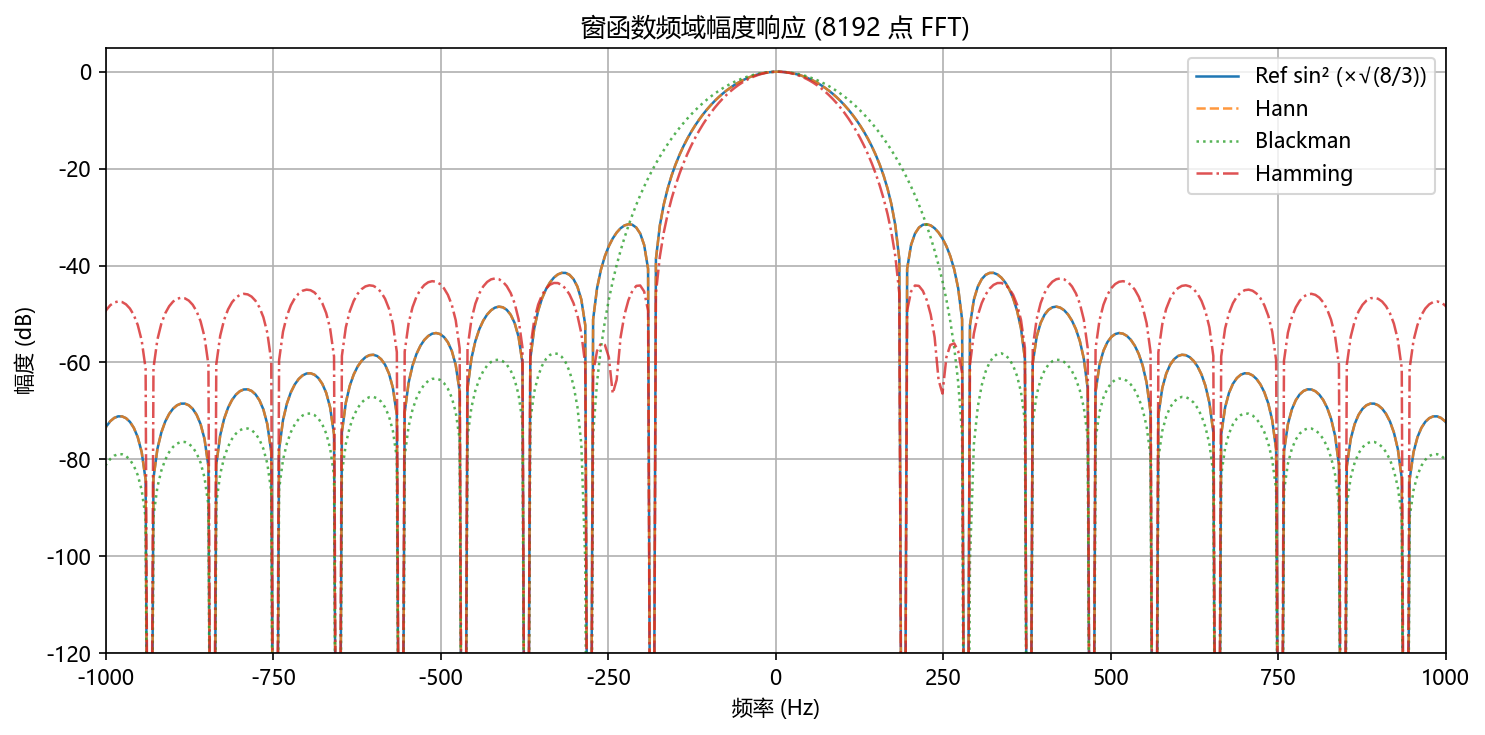

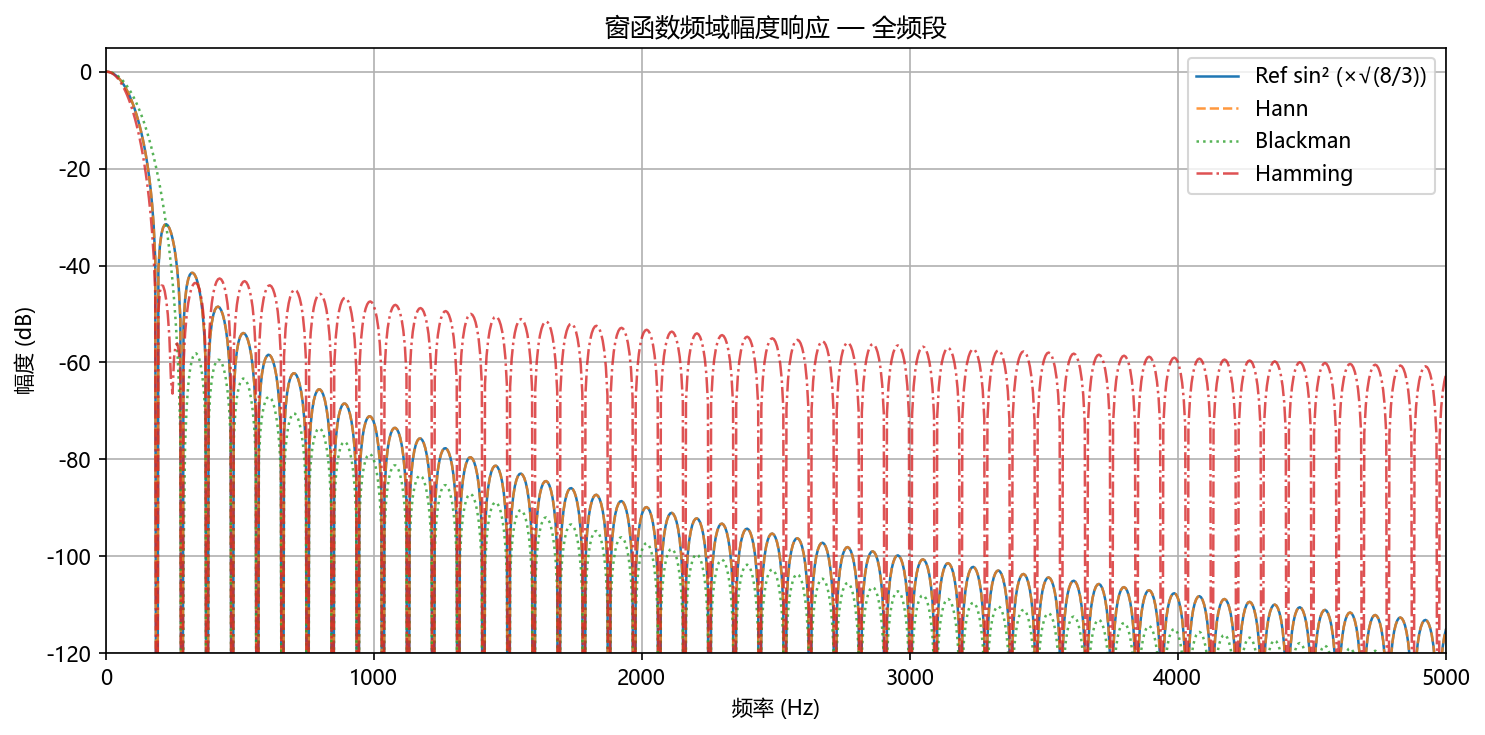

In [17]:
def window_spectrum(w, fft_n=8192, fs=48000):
    """计算窗函数的归一化幅度频谱 (dB)"""
    X = fft.fft(w, fft_n)
    X = fft.fftshift(X)  # 零频居中
    mag = np.abs(X)
    mag_db = 20 * np.log10(mag / mag.max() + 1e-12)
    freq = np.linspace(-fs/2, fs/2, fft_n)
    return freq, mag_db

def compute_metrics(w, fft_n=8192, fs=48000):
    """计算主瓣宽度 (-3dB) 和最大旁瓣 (dB)"""
    X = fft.fft(w, fft_n)
    X = fft.fftshift(X)
    mag = np.abs(X)
    mag_db = 20 * np.log10(mag / mag.max() + 1e-12)
    freq = np.linspace(-fs/2, fs/2, fft_n)

    # 找到主瓣边界 (-3dB 点)
    center = fft_n // 2
    mainlobe_mask = mag_db > -3
    # 从中心向两边找
    left = center
    while left > 0 and mag_db[left] > -3:
        left -= 1
    right = center
    while right < fft_n - 1 and mag_db[right] > -3:
        right += 1
    mainlobe_bw = (freq[right] - freq[left])

    # 最大旁瓣: 在主瓣之外找
    sidelobe_region = np.concatenate([mag_db[:left-10], mag_db[right+10:]])
    max_sidelobe = sidelobe_region.max()

    return mainlobe_bw, max_sidelobe

fft_n = 8192
freq, spec_ref = window_spectrum(w_ref, fft_n, fs)
_, spec_hann = window_spectrum(w_hann, fft_n, fs)
_, spec_black = window_spectrum(w_black, fft_n, fs)
_, spec_hamm = window_spectrum(w_hamm, fft_n, fs)

# 计算指标
metrics = {}
for name, w in [('Ref sin²', w_ref), ('Hann', w_hann), ('Blackman', w_black), ('Hamming', w_hamm)]:
    bw, sidelobe = compute_metrics(w, fft_n, fs)
    metrics[name] = (bw, sidelobe)
    print(f"{name:12s}: 主瓣 -3dB 带宽 = {bw:.1f} Hz, 最大旁瓣 = {sidelobe:.1f} dB")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq, spec_ref, label='Ref sin² (×√(8/3))', linewidth=1.2)
ax.plot(freq, spec_hann, '--', label='Hann', linewidth=1.2, alpha=0.8)
ax.plot(freq, spec_black, ':', label='Blackman', linewidth=1.2, alpha=0.8)
ax.plot(freq, spec_hamm, '-.', label='Hamming', linewidth=1.2, alpha=0.8)

ax.set_xlabel('频率 (Hz)')
ax.set_ylabel('幅度 (dB)')
ax.set_title('窗函数频域幅度响应 (8192 点 FFT)')
ax.legend()
ax.set_xlim(-1000, 1000)
ax.set_ylim(-120, 5)
fig.tight_layout()
plt.show()

# 全频段视图
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(freq, spec_ref, label='Ref sin² (×√(8/3))', linewidth=1.2)
ax2.plot(freq, spec_hann, '--', label='Hann', linewidth=1.2, alpha=0.8)
ax2.plot(freq, spec_black, ':', label='Blackman', linewidth=1.2, alpha=0.8)
ax2.plot(freq, spec_hamm, '-.', label='Hamming', linewidth=1.2, alpha=0.8)
ax2.set_xlabel('频率 (Hz)')
ax2.set_ylabel('幅度 (dB)')
ax2.set_title('窗函数频域幅度响应 — 全频段')
ax2.legend()
ax2.set_xlim(0, 5000)
ax2.set_ylim(-120, 5)
fig2.tight_layout()
plt.show()

## 4. COLA 性质验证

验证各窗在不同重叠率下是否满足 **Constant Overlap-Add (COLA)** 性质。相位声码器需要 COLA 窗才能无失真重建。

重叠率：2x (50%)、4x (75%)、8x (87.5%) — 对应 hop = N/2, N/4, N/8

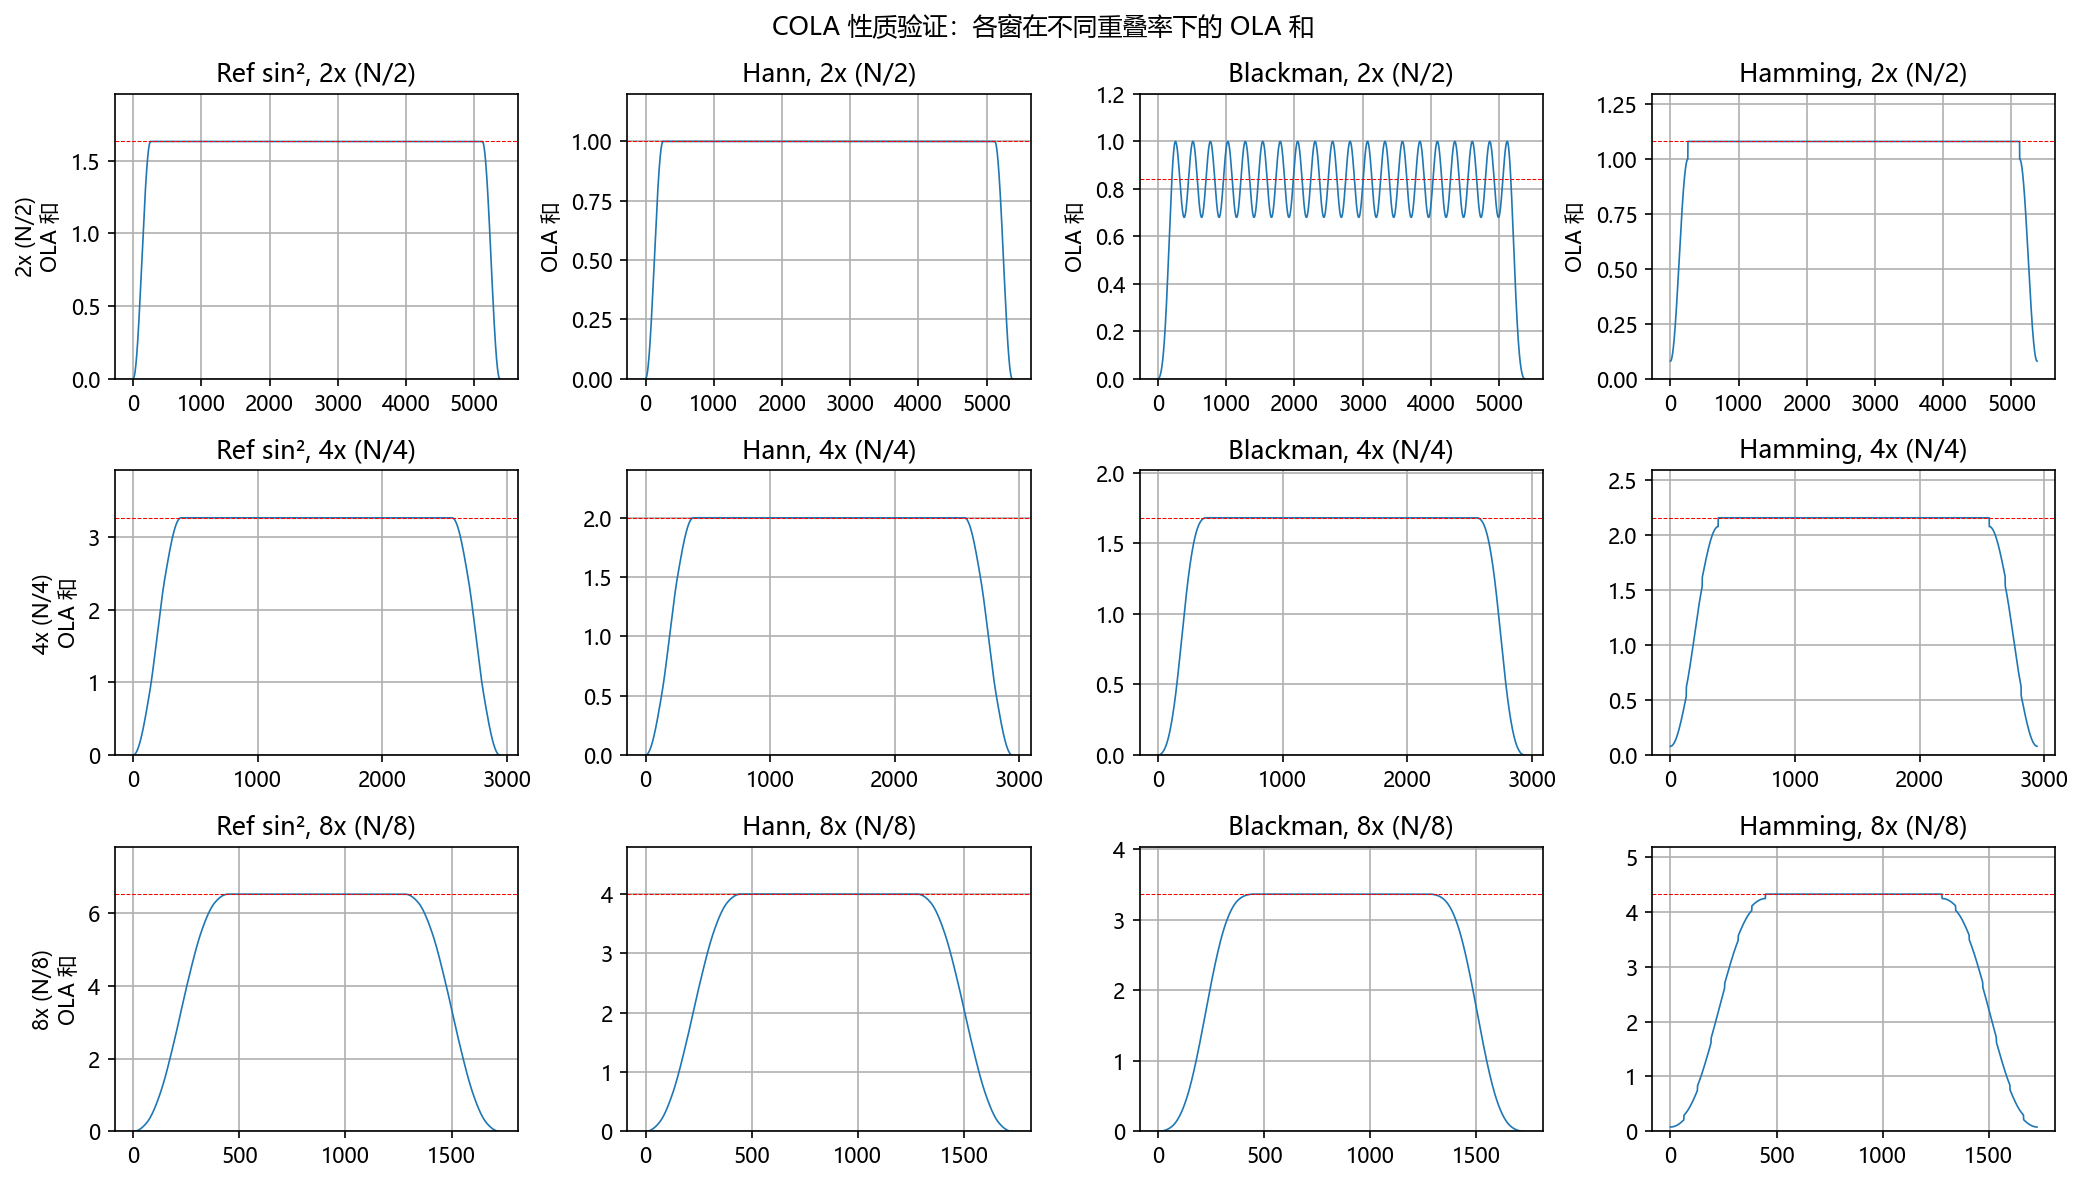


COLA 误差汇总 (波纹 dB)：
窗函数            2x (N/2)   4x (N/4)   8x (N/8)
--------------------------------------------
Ref sin²       1.93e-15   3.86e-15   3.86e-15
Hann           3.86e-15   1.93e-15   1.93e-15
Blackman       1.51e+00   3.86e-15   3.86e-15
Hamming        1.93e-15   3.86e-15   3.86e-15


In [18]:
def check_cola(w, hop, name=''):
    """检查窗函数在给定 hop 下的 COLA 性质"""
    N = len(w)
    # 生成多帧重叠的信号
    n_frames = 20
    total_len = N + (n_frames - 1) * hop
    accum = np.zeros(total_len)
    for i in range(n_frames):
        pos = i * hop
        accum[pos:pos+N] += w

    # 裁剪中间稳定区域
    stable = accum[N:total_len-N]
    mean_val = stable.mean()
    max_dev = np.max(np.abs(stable - mean_val))
    ripple_db = 20 * np.log10(1 + max_dev/mean_val) if mean_val > 0 else np.inf
    return mean_val, max_dev, ripple_db, accum

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
windows = [('Ref sin²', w_ref), ('Hann', w_hann), ('Blackman', w_black), ('Hamming', w_hamm)]
hops = [('2x (N/2)', N//2), ('4x (N/4)', N//4), ('8x (N/8)', N//8)]

for row, (hop_name, hop) in enumerate(hops):
    for col, (wname, w) in enumerate(windows):
        ax = axes[row, col]
        mean_val, max_dev, ripple_db, accum = check_cola(w, hop, wname)
        ax.plot(accum, linewidth=0.8)
        ax.axhline(mean_val, color='r', ls='--', lw=0.5)
        ax.set_title(f'{wname}, {hop_name}')
        ax.set_ylim(0, max(accum)*1.2)
        if row == 0:
            ax.set_ylabel('OLA 和')
        if col == 0:
            ax.set_ylabel(f'{hop_name}\nOLA 和')

fig.suptitle('COLA 性质验证：各窗在不同重叠率下的 OLA 和', fontsize=12)
fig.tight_layout()
plt.show()

print('\nCOLA 误差汇总 (波纹 dB)：')
print(f'{"窗函数":12s} {"2x (N/2)":>10s} {"4x (N/4)":>10s} {"8x (N/8)":>10s}')
print('-' * 44)
for wname, w in windows:
    vals = []
    for _, hop in hops:
        _, _, ripple_db, _ = check_cola(w, hop, wname)
        vals.append(f'{ripple_db:.2e}' if ripple_db < 100 else '  ∞  ')
    print(f'{wname:12s} {vals[0]:>10s} {vals[1]:>10s} {vals[2]:>10s}')

## 5. 综合对比表

各窗函数的关键指标汇总。

In [21]:
from IPython.display import display, HTML

html = '<table border="1" style="border-collapse:collapse">'
html += '<tr><th>窗函数</th><th>主瓣 -3dB (Hz)</th><th>最大旁瓣 (dB)</th>'
html += '<th>COLA 4x 波纹 (dB)</th></tr>'

for wname, w in windows:
    bw, sidelobe = compute_metrics(w, fft_n, fs)
    _, _, ripple_4x, _ = check_cola(w, N//4, wname)
    ripple_str = f'{ripple_4x:.2e}' if ripple_4x < 100 else '∞'
    html += f'<tr><td>{wname}</td><td>{bw:.1f}</td><td>{sidelobe:.1f}</td>'
    html += f'<td>{ripple_str}</td></tr>'

html += '</table>'
display(HTML(html))

窗函数,主瓣 -3dB (Hz),最大旁瓣 (dB),COLA 4x 波纹 (dB)
Ref sin²,140.6,-12.4,3.86e-15
Hann,140.6,-12.4,1.93e-15
Blackman,164.1,-10.6,3.86e-15
Hamming,128.9,-13.6,3.86e-15
